In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from numpy.linalg import inv  
np.random.seed(0) 
x = np.linspace(0, 10, 100) 
y = np.sin(x) + np.random.normal(scale=0.2, size=x.shape) 
x = x.reshape(-1, 1) 
y = y.reshape(-1, 1)

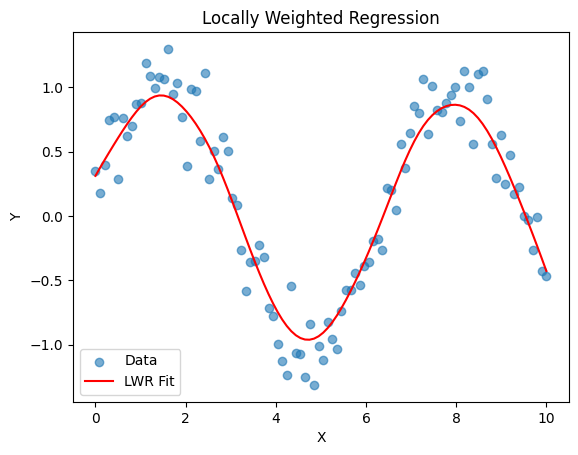

In [5]:
def local_weighted_regression(x_query, X, y, tau): 
    """Performs locally weighted regression for a single query point.""" 
    m = X.shape[0] 
    X_b = np.hstack([np.ones((m, 1)), X])
    x_query_b = np.hstack([1, x_query]) 
    W = np.diag(np.exp(-np.sum((X - x_query)**2, axis=1) / (2 * tau**2))) 
    theta = inv(X_b.T @ W @ X_b) @ X_b.T @ W @ y 
    return x_query_b @ theta 
tau = 0.5 
y_pred = np.array([local_weighted_regression(xi, x, y, tau) for xi in x])  
plt.scatter(x, y, label="Data", alpha=0.6) 
plt.plot(x, y_pred, color='red', label="LWR Fit") 
plt.xlabel("X") 
plt.ylabel("Y") 
plt.legend() 
plt.title("Locally Weighted Regression") 
plt.show()